# Voyage Fuel Optimizer

Use the trained fuel model to find fuel-optimal speeds for a voyage, given an ETA constraint.

## Adding a speed–fuel relationship

Our Random Forest model predicts fuel consumption for a given ship, route, weather, and engine efficiency, but it does not explicitly include speed as a feature. In reality, fuel use increases non‑linearly with speed due to hydrodynamic resistance (often approximated as proportional to speed³).

To create a realistic voyage optimizer, we:
- Use the RF model to estimate a **base fuel per day** at a chosen **reference speed** (e.g., 12 knots).
- Scale this base fuel with speed using a cubic relationship:

$$
\text{fuel_per_day}(v) = \text{fuel_base} \times \left(\frac{v}{v_{\text{ref}}}\right)^3
$$

This introduces a trade‑off: higher speeds reduce travel time but increase fuel per day, leading to a meaningful optimal speed that minimizes total fuel for a given ETA.

In [2]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = joblib.load("../models/fuel_model_rf_v1.joblib")

feature_cols = [
    "ship_type", "route_id", "fuel_type", "weather_conditions", "month",
    "distance", "engine_efficiency"
]

In [3]:
# Voyage definition
voyage = {
    "route_id": "Port Harcourt-Lagos",
    "ship_type": "Oil Service Boat",
    "fuel_type": "HFO",
    "weather_conditions": "Moderate",
    "month": "February",
    "distance": 128.52,
    "engine_efficiency": 92.98,
    "eta_max_hours": 12.0,
    "v_ref": 12.0  # reference speed for cubic scaling
}

# Speed range to test
speeds = np.linspace(8, 18, 41)

results = []

In [4]:
# Build one feature row for the base voyage
base_row = pd.DataFrame([{
    "ship_type": voyage["ship_type"],
    "route_id": voyage["route_id"],
    "fuel_type": voyage["fuel_type"],
    "weather_conditions": voyage["weather_conditions"],
    "month": voyage["month"],
    "distance": voyage["distance"],
    "engine_efficiency": voyage["engine_efficiency"],
}])

# Ensure correct dtypes
for c in ["ship_type", "route_id", "fuel_type", "weather_conditions", "month"]:
    base_row[c] = base_row[c].astype(str)
base_row["distance"] = base_row["distance"].astype(float)
base_row["engine_efficiency"] = base_row["engine_efficiency"].astype(float)

# Base fuel per day from the model
fuel_base = model.predict(base_row[feature_cols])[0]
print("Base fuel/day (model):", fuel_base)

Base fuel/day (model): 4176.202233333317


In [5]:
# Loop over speeds
for sp in speeds:
    time_hours = voyage["distance"] / sp
    
    # Skip speeds that don't meet ETA constraint
    if time_hours > voyage["eta_max_hours"]:
        continue
    
    # Cubic speed scaling
    v_ref = voyage["v_ref"]
    fuel_per_day = fuel_base * (sp / v_ref) ** 3
    
    # Total fuel for the voyage
    total_fuel = fuel_per_day * (time_hours / 24.0)
    
    results.append({
        "speed": sp,
        "time_hours": time_hours,
        "fuel_per_day": fuel_per_day,
        "total_fuel": total_fuel
    })

res_df = pd.DataFrame(results)

In [10]:
if res_df.empty:
    print("No feasible speed found that meets the ETA constraint.")
else:
    opt = res_df.loc[res_df["total_fuel"].idxmin()]
    
    print("Voyage:", voyage["route_id"])
    print("ETA constraint: ≤", voyage["eta_max_hours"], "hours")
    print("Reference speed (v_ref):", voyage["v_ref"], "knots")
    print("Base fuel/day (model):", fuel_base, "liters")
    print()
    print("Optimal speed (min total fuel, meeting ETA):")
    print(f"  Speed:       {opt['speed']:.2f} knots")
    print(f"  Time:        {opt['time_hours']:.2f} hours")
    print(f"  Fuel/day:    {opt['fuel_per_day']:.2f} liters")
    print(f"  Total fuel:  {opt['total_fuel']:.2f} liters")
    print()
    print("Speed range tested:", speeds.min(), "–", speeds.max(), "knots")
    print("Feasible speeds (meeting ETA):", res_df["speed"].min(), "–", res_df["speed"].max(), "knots")

Voyage: Port Harcourt-Lagos
ETA constraint: ≤ 12.0 hours
Reference speed (v_ref): 12.0 knots
Base fuel/day (model): 4176.202233333317 liters

Optimal speed (min total fuel, meeting ETA):
  Speed:       10.75 knots
  Time:        11.96 hours
  Fuel/day:    3002.36 liters
  Total fuel:  1495.60 liters

Speed range tested: 8.0 – 18.0 knots
Feasible speeds (meeting ETA): 10.75 – 18.0 knots


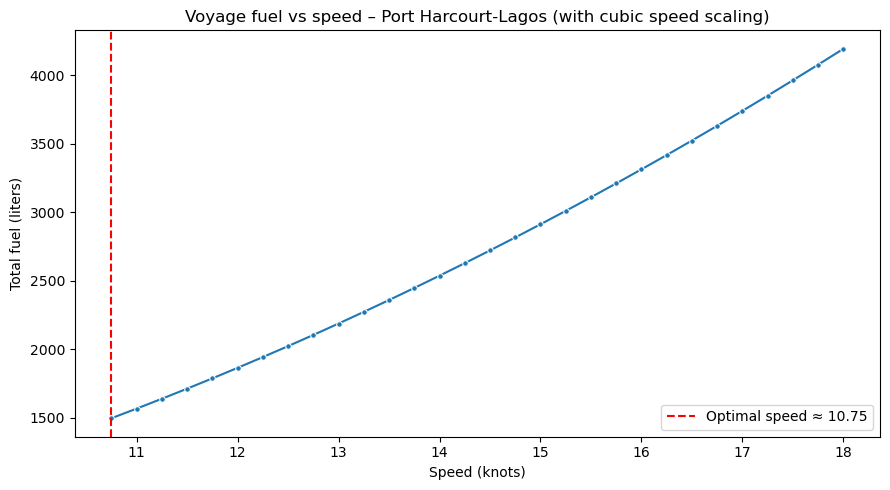

In [11]:
# Plot: total fuel vs speed
plt.figure(figsize=(9,5))
sns.lineplot(data=res_df, x="speed", y="total_fuel", marker="o", markersize=4)
plt.axvline(opt["speed"], color="red", linestyle="--", label=f"Optimal speed ≈ {opt['speed']:.2f}")
plt.xlabel("Speed (knots)")
plt.ylabel("Total fuel (liters)")
plt.title(f"Voyage fuel vs speed – {voyage['route_id']} (with cubic speed scaling)")
plt.legend()
plt.tight_layout()
plt.show()

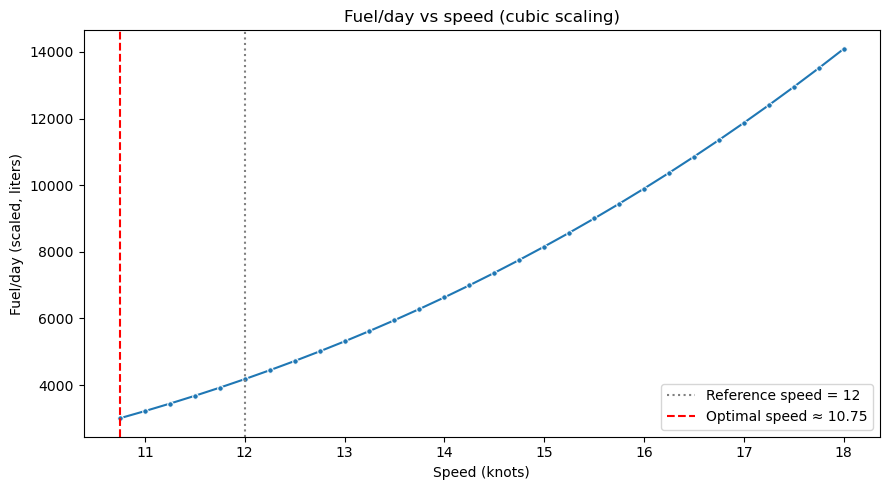

In [12]:
# Plot: fuel_per_day vs speed
plt.figure(figsize=(9,5))
sns.lineplot(data=res_df, x="speed", y="fuel_per_day", marker="o", markersize=4)
plt.axvline(voyage["v_ref"], color="gray", linestyle=":", label=f"Reference speed = {voyage['v_ref']:.0f}")
plt.axvline(opt["speed"], color="red", linestyle="--", label=f"Optimal speed ≈ {opt['speed']:.2f}")
plt.xlabel("Speed (knots)")
plt.ylabel("Fuel/day (scaled, liters)")
plt.title("Fuel/day vs speed (cubic scaling)")
plt.legend()
plt.tight_layout()
plt.show()

## Results: Port Harcourt–Lagos

For the Port Harcourt–Lagos voyage (distance ≈ 128.52, Moderate weather, engine efficiency ≈ 92.98) and an ETA constraint of 12 hours, the optimizer identifies an optimal speed of about **10.75 knots
**, corresponding to a travel time of ~12 hours.

At this speed:
- Fuel/day (with cubic speed scaling): ~3002 liters
- Total fuel for the leg: ~1496 liters

## Key finding

The optimizer favors **slow steaming** (lowest feasible speed that meets the ETA), which aligns with industry practice for reducing bunker costs and emissions when schedule flexibility exists.